<a href="https://colab.research.google.com/github/zephyrstorm123/CapstoneProject_MMDC_Apylitics/blob/First_Iteration_09092025/capstone_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### CAPSTONE PROJECT

#### Machine Learning Model Predicting Hearing Loss in Newborn

This project aims to build a machine learning model that can predict if a certain newborn will develop hearing loss based on different risk factors.

Predictive Model:

1. Logistic Regression Model
2. Random Forest Classifier
3. XGBoost Classifier

The models to be used are CLASSIFICATION MODELS

Dependent Variables

1. Hyperbilirubinemia requiring transfusion
2. Ventilation > 46 hours
3. NICU admission > 48 hours
4. Ototoxic medication
5. Family history of permanent childhood hearing loss
6. Craniofacial anomalies with deformed pinna or ear canal
7. In-utero infections
8. Features with syndromes.

Independent Variable

1. Hearing Loss

The dataset will contain only 0 or 1

1 = Presence |
0 = Absence

Requirements

Matplotlib
Scipy
Numpy
Pandas




In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
import IPython.display as display

CREATING MOCK DATA

In [3]:
#Creating columns for the mock data
columns = [
    "hyperbilirubinemia_transfusion",
    "ventilation_over_46h",
    "nicu_admission_over_48h",
    "ototoxic_medication",
    "family_history_hearing_loss",
    "craniofacial_anomaly",
    "in_utero_infection",
    "syndromic_features",
    "hearing_loss"
]

np.random.seed(42)  # For reproducibility
n_samples = 3000

In [4]:
#Creating mock data
data = np.random.randint(0, 2, size=(n_samples, len(columns)))

In [5]:
df = pd.DataFrame(data, columns=columns)

In [6]:
print(df.head())  # Display the first few rows of the DataFrame

   hyperbilirubinemia_transfusion  ventilation_over_46h  \
0                               0                     1   
1                               1                     0   
2                               1                     0   
3                               1                     1   
4                               1                     0   

   nicu_admission_over_48h  ototoxic_medication  family_history_hearing_loss  \
0                        0                    0                            0   
1                        0                    0                            0   
2                        1                    0                            1   
3                        1                    0                            0   
4                        0                    0                            0   

   craniofacial_anomaly  in_utero_infection  syndromic_features  hearing_loss  
0                     1                   0                   0             0  
1   

In [7]:
#Save datafram to CSV

df.to_csv('mock_data.csv', index=False)

In [8]:
# Set pandas display options

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

In [9]:
# Display the DataFrame in the notebook

display.display(df)


,hyperbilirubinemia_transfusion,ventilation_over_46h,nicu_admission_over_48h,ototoxic_medication,family_history_hearing_loss,craniofacial_anomaly,in_utero_infection,syndromic_features,hearing_loss
0,0,1,0,0,0,1,0,0,0
1,1,0,0,0,0,1,0,1,1
2,1,0,1,0,1,1,1,1,1
3,1,1,1,0,0,1,1,1,0
4,1,0,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...
2995,1,1,1,0,1,1,0,1,0
2996,1,1,1,0,1,0,1,1,0
2997,0,1,0,1,1,0,0,0,1
2998,0,1,0,0,0,0,0,1,0


DATA CLEANING AND EXPLORATION

In [10]:
#Split dependent from independent variable

independent_variable = df.copy()
independent_variable = independent_variable.drop(columns=['hearing_loss'])
independent_variable

,hyperbilirubinemia_transfusion,ventilation_over_46h,nicu_admission_over_48h,ototoxic_medication,family_history_hearing_loss,craniofacial_anomaly,in_utero_infection,syndromic_features
0,0,1,0,0,0,1,0,0
1,1,0,0,0,0,1,0,1
2,1,0,1,0,1,1,1,1
3,1,1,1,0,0,1,1,1
4,1,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...
2995,1,1,1,0,1,1,0,1
2996,1,1,1,0,1,0,1,1
2997,0,1,0,1,1,0,0,0
2998,0,1,0,0,0,0,0,1


In [11]:
dependent_variable = df['hearing_loss']
print(dependent_variable)

0       0
1       1
2       1
3       0
4       1
       ..
2995    0
2996    0
2997    1
2998    0
2999    0
Name: hearing_loss, Length: 3000, dtype: int64


In [12]:
# Test for Linearity
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

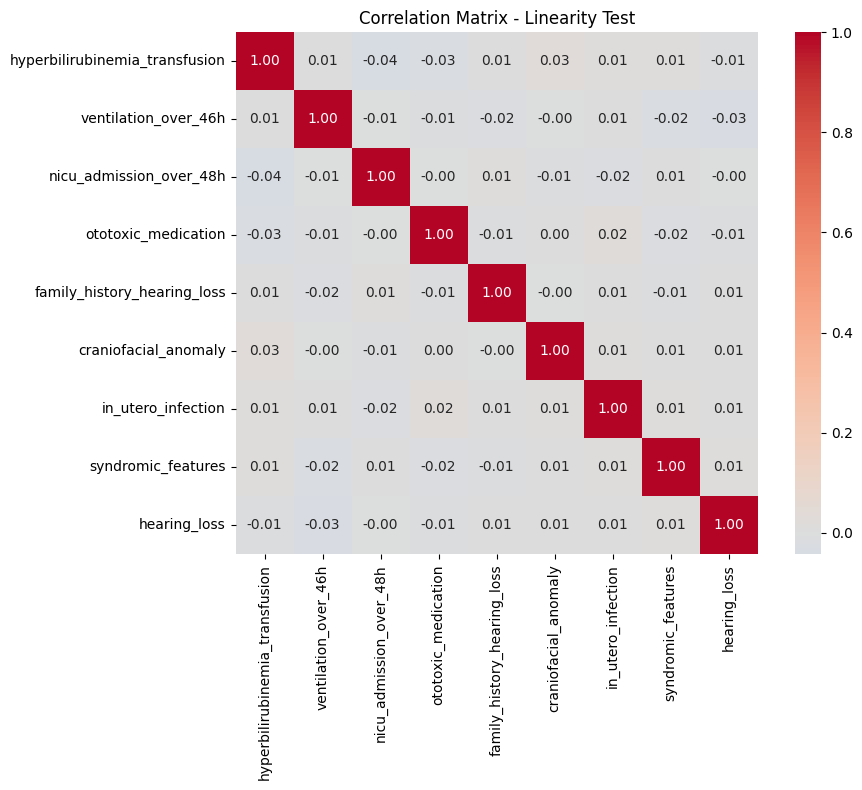

In [13]:
# 1. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Correlation Matrix - Linearity Test')
plt.tight_layout()
plt.show()

In [14]:
# 2. Pairwise correlation with target variable
print("Correlation with Hearing Loss (Target Variable):")
print("-" * 45)
for col in independent_variable.columns:
    corr, p_value = pearsonr(df[col], df['hearing_loss'])
    print(f"{col:<30}: {corr:.3f} (p-value: {p_value:.3f})")
    if p_value < 0.05:
        print(f"  - Significant correlation with {col} (p-value < 0.05)")
    else:
        print(f"  - No significant correlation with {col} (p-value >= 0.05)")


Correlation with Hearing Loss (Target Variable):
---------------------------------------------
hyperbilirubinemia_transfusion: -0.009 (p-value: 0.607)
  - No significant correlation with hyperbilirubinemia_transfusion (p-value >= 0.05)
ventilation_over_46h          : -0.032 (p-value: 0.083)
  - No significant correlation with ventilation_over_46h (p-value >= 0.05)
nicu_admission_over_48h       : -0.003 (p-value: 0.862)
  - No significant correlation with nicu_admission_over_48h (p-value >= 0.05)
ototoxic_medication           : -0.007 (p-value: 0.695)
  - No significant correlation with ototoxic_medication (p-value >= 0.05)
family_history_hearing_loss   : 0.007 (p-value: 0.682)
  - No significant correlation with family_history_hearing_loss (p-value >= 0.05)
craniofacial_anomaly          : 0.010 (p-value: 0.598)
  - No significant correlation with craniofacial_anomaly (p-value >= 0.05)
in_utero_infection            : 0.010 (p-value: 0.597)
  - No significant correlation with in_utero_in

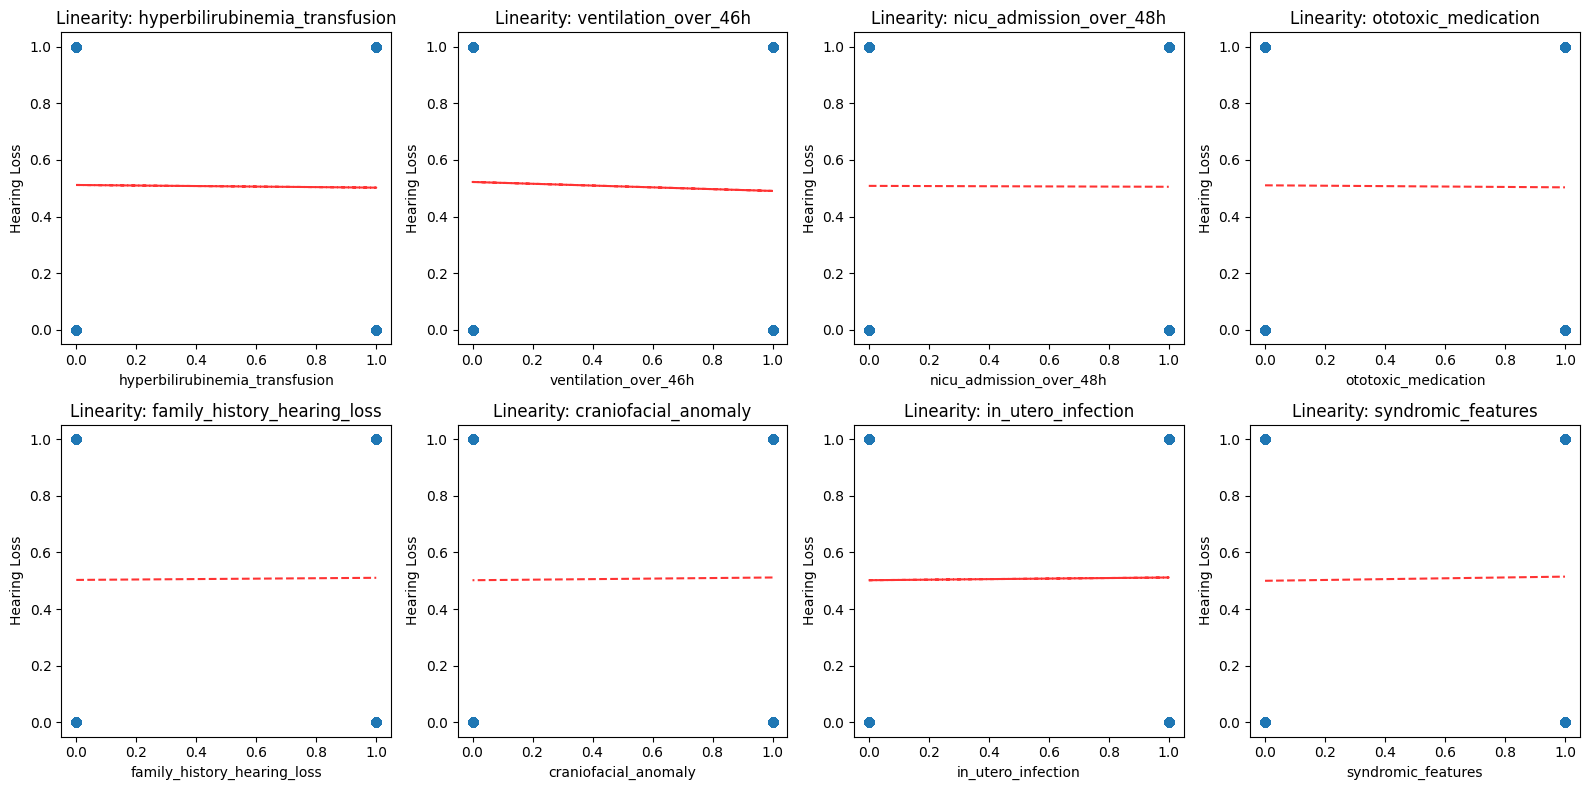

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, col in enumerate(independent_variable.columns):
    axes[i].scatter(df[col], df['hearing_loss'], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Hearing Loss')
    axes[i].set_title(f'Linearity: {col}')

    # Add trend line
    z = np.polyfit(df[col], df['hearing_loss'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[col], p(df[col]), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

In [16]:
# 4. Variance Inflation Factor (VIF) for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data["Variable"] = independent_variable.columns
vif_data["VIF"] = [variance_inflation_factor(independent_variable.values, i)
                   for i in range(independent_variable.shape[1])]

print("\nVariance Inflation Factor (VIF):")
print("VIF > 5 indicates multicollinearity concerns")
print("-" * 40)
print(vif_data.sort_values('VIF', ascending=False))


Variance Inflation Factor (VIF):
VIF > 5 indicates multicollinearity concerns
----------------------------------------
                        Variable       VIF
6             in_utero_infection  1.839154
5           craniofacial_anomaly  1.835008
4    family_history_hearing_loss  1.828311
0  hyperbilirubinemia_transfu...  1.791677
3            ototoxic_medication  1.748092
2        nicu_admission_over_48h  1.743361
1           ventilation_over_46h  1.719700
7             syndromic_features  1.709456


Data Preprocessing

In [17]:
#Open CSV file in VS Code

data = pd.read_csv('mock_data.csv')
display.display(data)

,hyperbilirubinemia_transfusion,ventilation_over_46h,nicu_admission_over_48h,ototoxic_medication,family_history_hearing_loss,craniofacial_anomaly,in_utero_infection,syndromic_features,hearing_loss
0,0,1,0,0,0,1,0,0,0
1,1,0,0,0,0,1,0,1,1
2,1,0,1,0,1,1,1,1,1
3,1,1,1,0,0,1,1,1,0
4,1,0,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...
2995,1,1,1,0,1,1,0,1,0
2996,1,1,1,0,1,0,1,1,0
2997,0,1,0,1,1,0,0,0,1
2998,0,1,0,0,0,0,0,1,0


In [18]:
#Removing rows with missing values
cleaned_data = data.dropna()

In [19]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [20]:
X

array([[0, 1, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 0, 1],
       [1, 0, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       [0, 1, 1, ..., 0, 0, 1]])

TRAINING USING LOGISTIC REGRESSION MODEL

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [22]:
classifier.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [23]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 1]
 [0 1]
 [0 1]
 ...
 [0 0]
 [0 1]
 [1 1]]


In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[120 173]
 [143 164]]


0.47333333333333333

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [26]:
# 1. Logistic Regression Hyperparameter Tuning
print("=== LOGISTIC REGRESSION HYPERPARAMETER TUNING ===")
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000, 2000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)
print(f"Best LR Parameters: {lr_grid.best_params_}")
print(f"Best LR CV Score: {lr_grid.best_score_:.4f}")

=== LOGISTIC REGRESSION HYPERPARAMETER TUNING ===
Best LR Parameters: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best LR CV Score: 0.5050


In [27]:
#Get predictions from the best logistic regression model

lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test)
y_pred_prob_lr = lr_best.predict_proba(X_test)[:, 1]

In [28]:
print(lr_grid.best_params_)

{'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


In [52]:
print(lr_grid.best_score_)

0.505


In [58]:
# Basic Classification Metrics

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc_roc = roc_auc_score(y_test, y_pred_prob_lr)

In [60]:
print("Logistic Regression Classification Report:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1 Score: {lr_f1:.4f}")
print(f"ROC AUC: {lr_auc_roc:.4f}")

Logistic Regression Classification Report:
Accuracy: 0.4867
Precision: 0.4987
Recall: 0.6319
F1 Score: 0.5575
ROC AUC: 0.4842


In [30]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

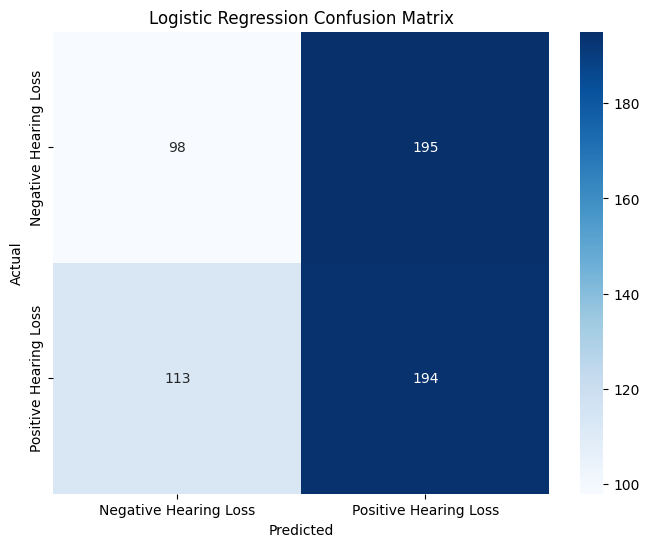

In [31]:
plt.figure(figsize = (8, 6)),
sns.heatmap(
    cm,
    annot=True,
    fmt = 'd',
    cmap='Blues',
    xticklabels=['Negative Hearing Loss', 'Positive Hearing Loss'],
    yticklabels=['Negative Hearing Loss', 'Positive Hearing Loss']
)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

TRAINING DATA ON RANDOM FOREST CLASSIFIER

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
rf_param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 5, 10, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features' : ['sqrt', 'log2'],
    'bootstrap' : [True, False]
}

In [34]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid = rf_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose= 1
)

In [35]:
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [3, 5, 10, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [36]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [37]:
print(rf_grid.best_score_)

0.51625


In [38]:
#Random Forest Performance Scores

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_pred_prob_rf = rf_best.predict_proba(X_test)[:, 1]

In [39]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_prob_rf)


In [40]:
print("Random Forest Classification Report:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"ROC AUC: {rf_roc_auc:.4f}")

Random Forest Classification Report:
Accuracy: 0.5150
Precision: 0.5255
Recall: 0.5375
F1 Score: 0.5314
ROC AUC: 0.5414


In [41]:
print("Confusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)


Confusion Matrix:


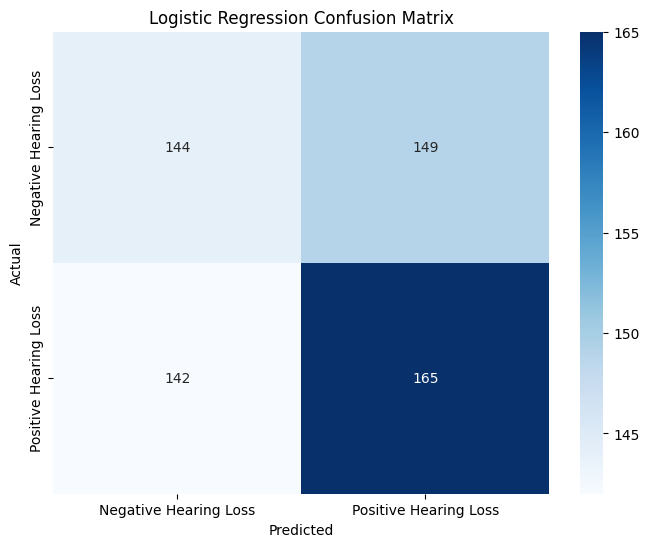

In [42]:
plt.figure(figsize = (8, 6)),
sns.heatmap(
    cm_rf,
    annot=True,
    fmt = 'd',
    cmap='Blues',
    xticklabels=['Negative Hearing Loss', 'Positive Hearing Loss'],
    yticklabels=['Negative Hearing Loss', 'Positive Hearing Loss']
)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

TRAINING DATA ON XGBoost CLASSIFICATION

In [43]:
%pip install xgboost
import xgboost as xgb

TRAINING THE DATA USING XGBoost CLASSIFICATION

In [45]:
xgb_param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [3, 5, 10],
    'learning_rate' : [0.01, 0.1, 0.2],
    'subsample' : [0.8, 0.9, 1.0]
}

In [46]:
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42),
    param_grid = xgb_param_grid,
    cv = 5,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose= 1
)

In [47]:
xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 200],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy', verbose=1)

In [48]:
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 50, 'subsample': 0.8}


In [50]:
print(xgb_grid.best_score_)

0.5154166666666666


In [53]:
#XGBoost Classifier Best Score

In [54]:
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test)
y_pred_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

In [55]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_pred_prob_xgb)

In [56]:
print("Random Forest Classification Report:")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1 Score: {xgb_f1:.4f}")
print(f"ROC AUC: {xgb_roc_auc:.4f}")

Random Forest Classification Report:
Accuracy: 0.5300
Precision: 0.5373
Recall: 0.5863
F1 Score: 0.5607
ROC AUC: 0.5438


In [63]:
#Confusion Matrix for XGBoost Classification

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

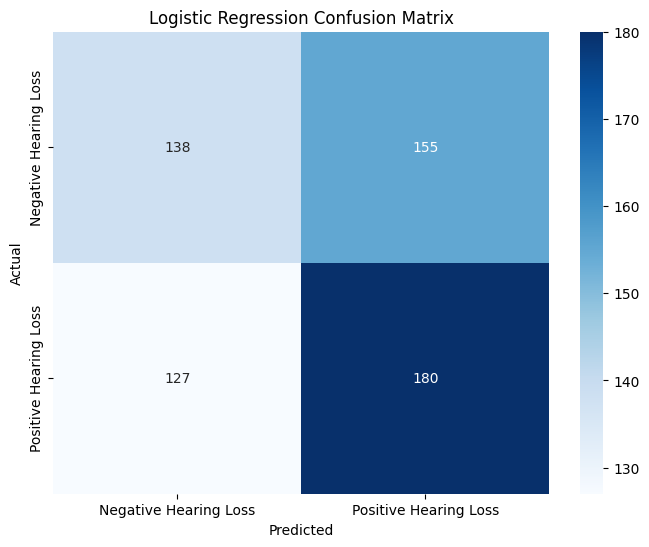

In [64]:
plt.figure(figsize = (8, 6)),
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt = 'd',
    cmap='Blues',
    xticklabels=['Negative Hearing Loss', 'Positive Hearing Loss'],
    yticklabels=['Negative Hearing Loss', 'Positive Hearing Loss']
)
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()